In [1]:
# env python3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

In [2]:
# load data
df = pd.read_csv("../data/spotify/tracks.csv")

print("Shape:", df.shape)
df.head()

Shape: (586672, 20)


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


In [3]:
# basic informations
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,586672.000000,5.866720e+05,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000
mean,27.570053,2.300512e+05,0.044086,0.563594,0.542036,5.221603,-10.206067,0.658797,0.104864,0.449863,0.113451,0.213935,0.552292,118.464857,3.873382
std,18.370642,1.265261e+05,0.205286,0.166103,0.251923,3.519423,5.089328,0.474114,0.179893,0.348837,0.266868,0.184326,0.257671,29.764108,0.473162
min,0.000000,3.344000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,1.750930e+05,0.000000,0.453000,0.343000,2.000000,-12.891000,0.000000,0.034000,0.096900,0.000000,0.098300,0.346000,95.600000,4.000000
50%,27.000000,2.148930e+05,0.000000,0.577000,0.549000,5.000000,-9.243000,1.000000,0.044300,0.422000,0.000024,0.139000,0.564000,117.384000,4.000000
75%,41.000000,2.638670e+05,0.000000,0.686000,0.748000,8.000000,-6.482000,1.000000,0.076300,0.785000,0.009550,0.278000,0.769000,136.321000,4.000000
max,100.000000,5.621218e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.971000,0.996000,1.000000,1.000000,1.000000,246.381000,5.000000


In [4]:
# data cleaning
df = df.drop_duplicates()
df = df.dropna()

print("After cleaning:", df.shape)

After cleaning: (586601, 20)


In [5]:
df.corr(numeric_only=True)['popularity'].sort_values(ascending=False)

popularity          1.000000
loudness            0.327001
energy              0.302178
explicit            0.211749
danceability        0.186878
time_signature      0.086713
tempo               0.071223
duration_ms         0.027638
key                 0.015306
valence             0.004558
mode               -0.033652
speechiness        -0.047415
liveness           -0.048735
instrumentalness   -0.236403
acousticness       -0.370723
Name: popularity, dtype: float64

In [6]:
# Convert duration
df['duration_min'] = df['duration_ms'] / 60000

# Engagement Score
df['engagement_score'] = (
    0.4 * df['popularity'] +
    20 * df['danceability'] +
    20 * df['energy'] +
    2 * df['duration_min']
)

In [7]:
# Normalize
df['engagement_score'] = (
    (df['engagement_score'] - df['engagement_score'].min()) /
    (df['engagement_score'].max() - df['engagement_score'].min())
)

# Categorize
df['engagement_level'] = pd.cut(
    df['engagement_score'],
    bins=[0, 0.3, 0.7, 1],
    labels=['Low', 'Medium', 'High']
)

df[['engagement_score', 'engagement_level']].head()

,engagement_score,engagement_level
0,0.133602,Low
1,0.105310,Low
2,0.085691,Low
3,0.066509,Low
4,0.077960,Low


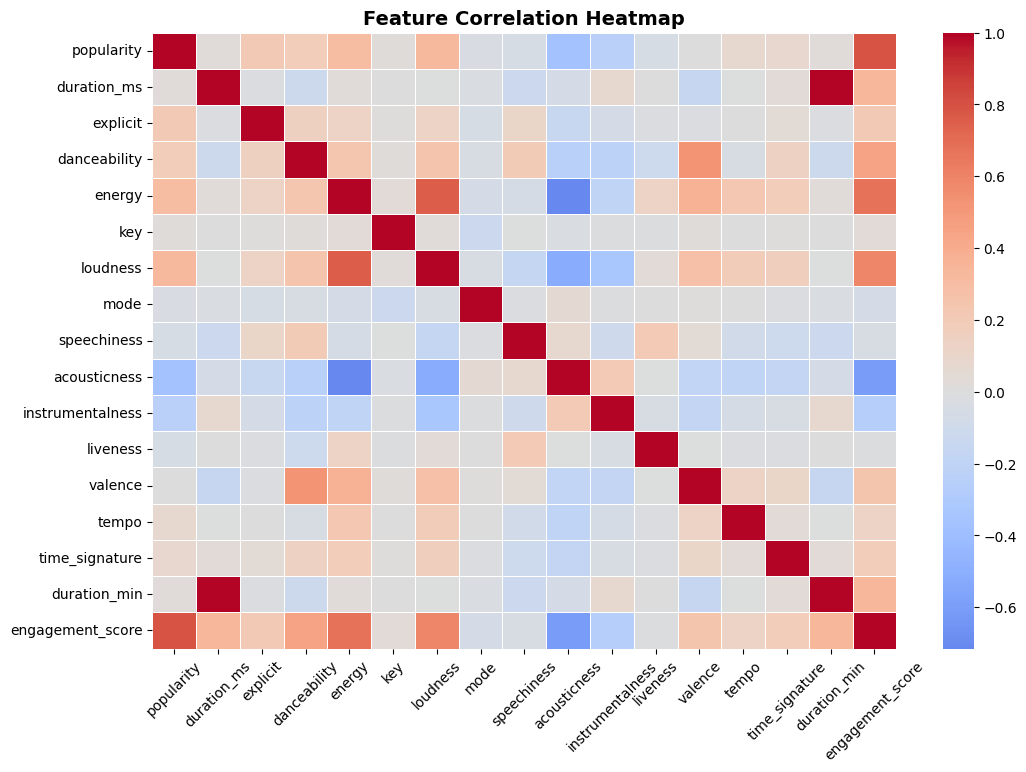

In [8]:
# correlation heatmap
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",   
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

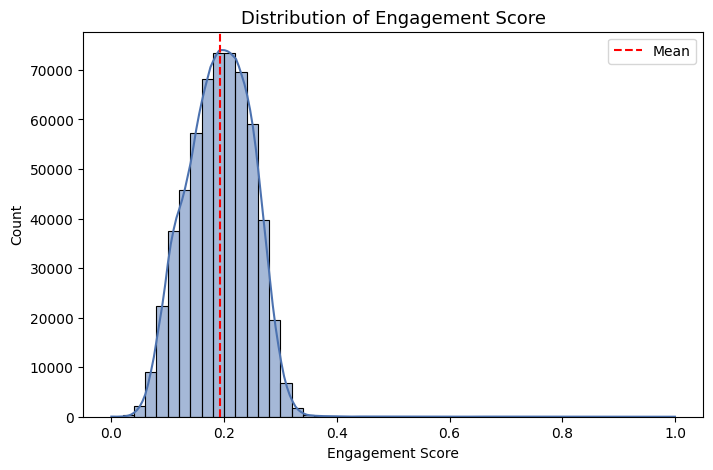

In [9]:
# engagement score distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df['engagement_score'],
    bins=50,
    kde=True,
    color="#4C72B0" 
)

plt.axvline(df['engagement_score'].mean(), color='red', linestyle='--', label='Mean')

plt.title("Distribution of Engagement Score", fontsize=13)
plt.xlabel("Engagement Score")
plt.ylabel("Count")
plt.legend()

plt.show()

C:\Users\adity\AppData\Local\Temp\ipykernel_11128\4193833737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\adity\AppData\Local\Prog

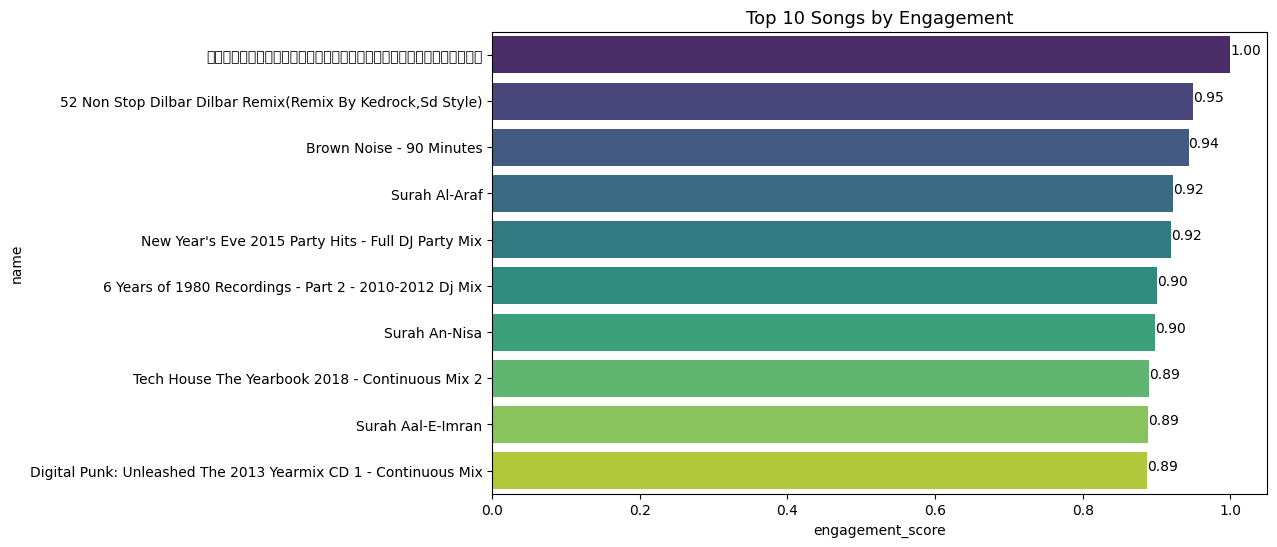

In [10]:
# top 10 songs by engagement
top_tracks = df.sort_values(by='engagement_score', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='engagement_score',
    y='name',
    data=top_tracks,
    palette="viridis"   
)

plt.title("Top 10 Songs by Engagement", fontsize=13)

# Add values on bars
for index, value in enumerate(top_tracks['engagement_score']):
    plt.text(value, index, f"{value:.2f}")

plt.show()

c:\Users\adity\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


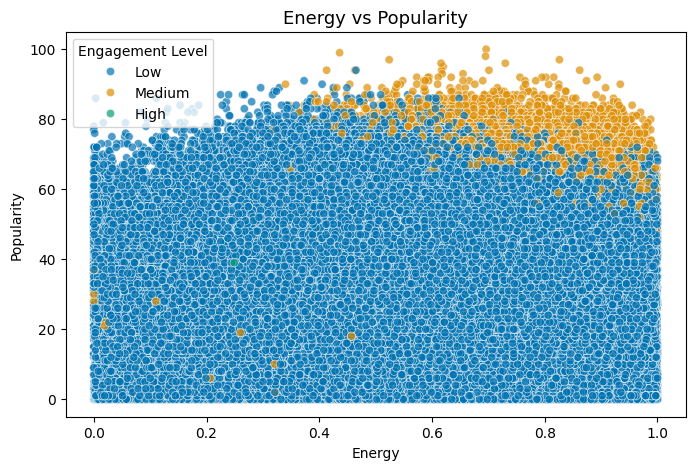

In [11]:
# energy vs popularity
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='energy',
    y='popularity',
    hue='engagement_level',
    data=df,
    palette="colorblind",
    alpha=0.7
)

plt.title("Energy vs Popularity", fontsize=13)
plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.legend(title="Engagement Level")

plt.show()


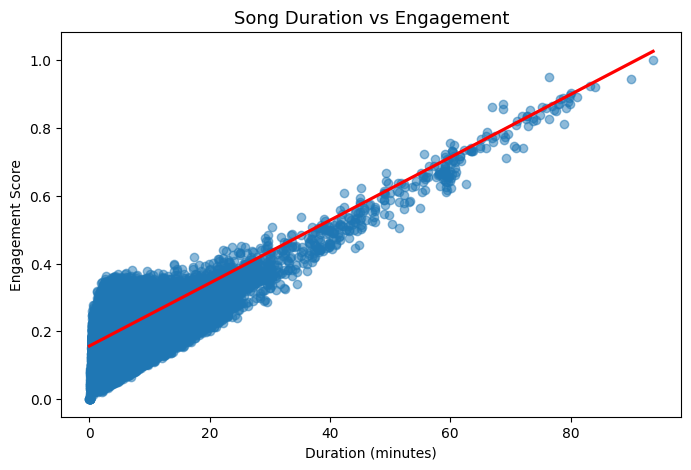

In [12]:
# duration vs engagement
plt.figure(figsize=(8,5))

sns.regplot(
    x='duration_min',
    y='engagement_score',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Song Duration vs Engagement", fontsize=13)
plt.xlabel("Duration (minutes)")
plt.ylabel("Engagement Score")

plt.show()

C:\Users\adity\AppData\Local\Temp\ipykernel_11128\732671984.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


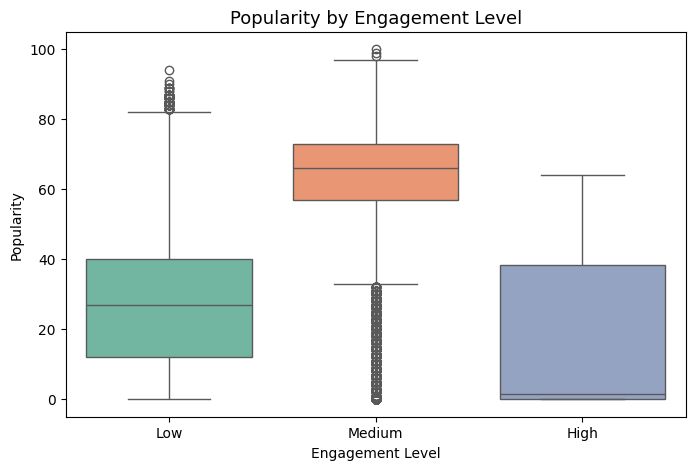

In [13]:
# popularity by engagement level
plt.figure(figsize=(8,5))

sns.boxplot(
    x='engagement_level',
    y='popularity',
    data=df,
    palette="Set2" 
)

plt.title("Popularity by Engagement Level", fontsize=13)
plt.xlabel("Engagement Level")
plt.ylabel("Popularity")

plt.show()

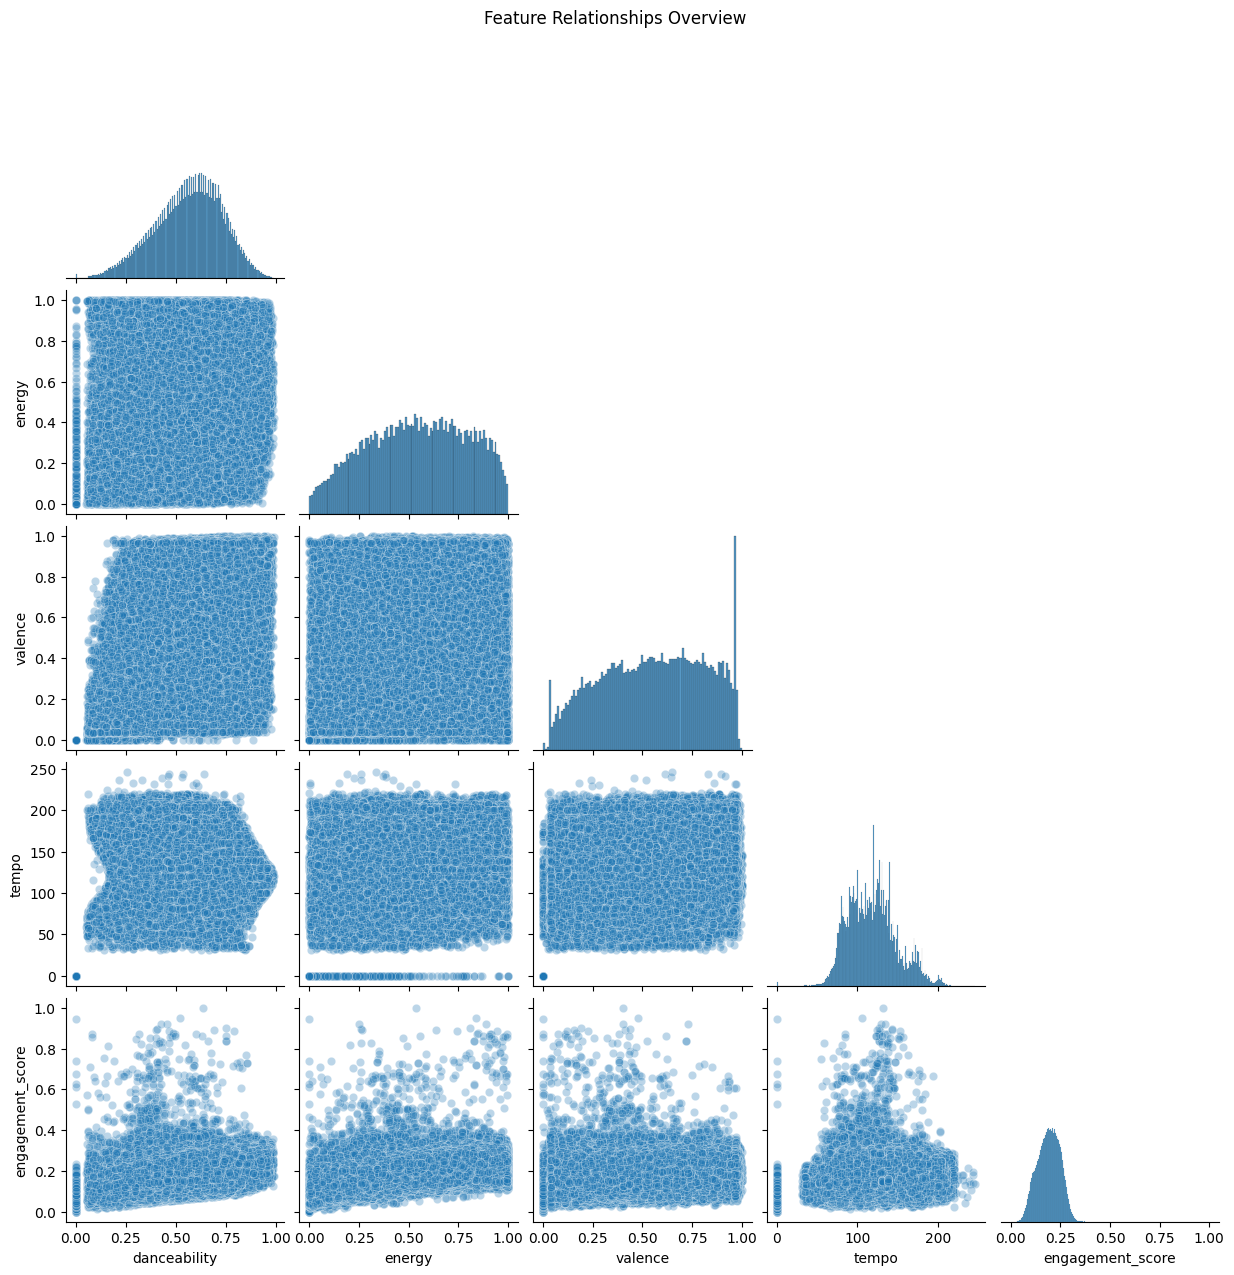

In [14]:
# pairplot of key features
sns.pairplot(
    df[['danceability','energy','valence','tempo','engagement_score']],
    corner=True,
    plot_kws={'alpha':0.3}
)

plt.suptitle("Feature Relationships Overview", y=1.02)
plt.show()

In [15]:
# insights
if df['duration_min'].mean() < 3:
    print("Insight: Shorter songs tend to dominate the platform.")

if df['energy'].corr(df['popularity']) > 0:
    print("Insight: High-energy songs are generally more popular.")

if df['engagement_score'].mean() < 0.5:
    print("Insight: Most songs have moderate engagement.")

if df['danceability'].corr(df['engagement_score']) > 0:
    print("Insight: Danceable tracks show higher engagement.")

Insight: High-energy songs are generally more popular.
Insight: Most songs have moderate engagement.
Insight: Danceable tracks show higher engagement.


In [16]:
# clustering
features = df[['danceability', 'energy', 'valence', 'tempo']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(scaled_features)


In [17]:
# interpret clusters
cluster_names = {
    0: "Chill ",
    1: "Party ",
    2: "Focus "
}

df['cluster_label'] = df['cluster'].map(cluster_names)

df[['cluster', 'cluster_label']].head()

,cluster,cluster_label
0,0,Chill
1,1,Party
2,0,Chill
3,0,Chill
4,0,Chill


In [18]:
# Create two groups (simulate A/B test)
high_energy = df[df['energy'] > df['energy'].median()]
low_energy = df[df['energy'] <= df['energy'].median()]

# Compare engagement
high_mean = high_energy['engagement_score'].mean()
low_mean = low_energy['engagement_score'].mean()

print(f"High Energy Avg Engagement: {high_mean:.3f}")
print(f"Low Energy Avg Engagement: {low_mean:.3f}")

lift = ((high_mean - low_mean) / low_mean) * 100
print(f"Lift: {lift:.2f}%")

High Energy Avg Engagement: 0.225
Low Energy Avg Engagement: 0.159
Lift: 41.96%


In [19]:
# statistical tests
from scipy.stats import ttest_ind

stat, p_value = ttest_ind(
    high_energy['engagement_score'],
    low_energy['engagement_score']
)

print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Insight: Difference is statistically significant ")
else:
    print("Insight: No strong statistical evidence ")

P-value: 0.0
Insight: Difference is statistically significant 


In [20]:
# final insights
print("\n BUSINESS INSIGHTS:\n")

if lift > 10:
    print("• Promote high-energy songs in playlists to boost engagement")

if df['danceability'].corr(df['engagement_score']) > 0:
    print("• Focus on danceable tracks for viral content strategy")

if df['duration_min'].corr(df['engagement_score']) < 0:
    print("• Optimize song length (shorter songs perform better)")

if df['engagement_score'].mean() < 0.5:
    print("• Majority content is mid-performing → opportunity to improve recommendations")


 BUSINESS INSIGHTS:

• Promote high-energy songs in playlists to boost engagement
• Focus on danceable tracks for viral content strategy
• Majority content is mid-performing → opportunity to improve recommendations


C:\Users\adity\AppData\Local\Temp\ipykernel_11128\2835688118.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


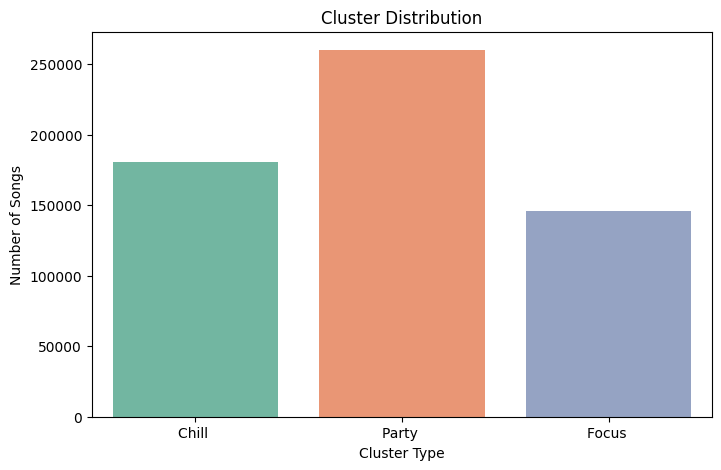

In [21]:
# cluster distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='cluster_label',
    data=df,
    palette='Set2'
)

plt.title("Cluster Distribution")
plt.xlabel("Cluster Type")
plt.ylabel("Number of Songs")

plt.show()

In [22]:
# clustering insights
cluster_summary = df.groupby('cluster_label')[
    ['danceability','energy','valence','tempo','engagement_score']
].mean()

cluster_summary

,danceability,energy,valence,tempo,engagement_score
cluster_label,,,,,
Chill,0.448582,0.310126,0.313256,101.469940,0.152870
Focus,0.486752,0.680765,0.534333,152.654938,0.202297
Party,0.686552,0.625209,0.728268,111.083318,0.213409


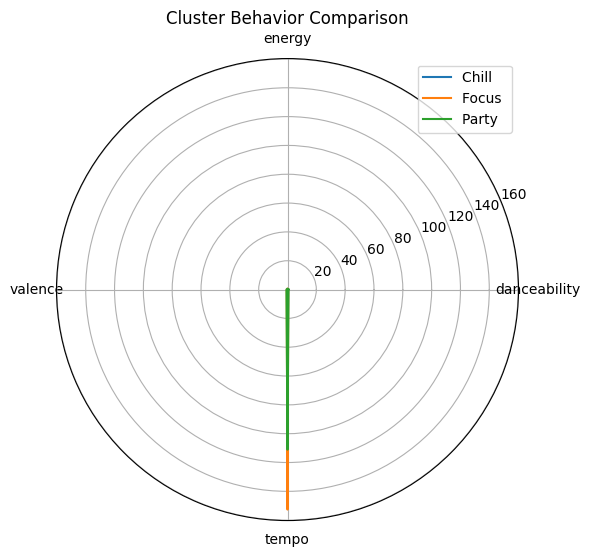

In [23]:
# radar chart(cluster comparison)
labels = ['danceability','energy','valence','tempo']
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(6,6))

for cluster in cluster_summary.index:
    values = cluster_summary.loc[cluster, labels].tolist()
    values += values[:1]
    
    plt.polar(angles, values, label=cluster)

plt.xticks(angles[:-1], labels)
plt.title("Cluster Behavior Comparison")
plt.legend()
plt.show()

In [24]:
# User profiling


def build_user_profile(selected_songs):
    if len(selected_songs) == 0:
        return None

    user_data = df[df['name'].isin(selected_songs)]

    if user_data.empty:
        return None

    user_vector = scaled_df.loc[user_data.index].mean().values.reshape(1, -1)

    return user_vector


def recommend_for_user(user_vector, top_n=5):
    similarities = cosine_similarity(user_vector, scaled_df)[0]

    top_indices = similarities.argsort()[::-1][:top_n]

    return df[['name', 'artists', 'engagement_level']].iloc[top_indices]

In [25]:
importance = df.corr(numeric_only=True)['engagement_score'].sort_values(ascending=False)

print("Top Drivers of Engagement:\n")
print(importance)

Top Drivers of Engagement:

engagement_score    1.000000
popularity          0.791964
energy              0.673068
loudness            0.584612
danceability        0.445445
cluster             0.343118
duration_ms         0.341733
duration_min        0.341733
valence             0.245219
explicit            0.214670
time_signature      0.184083
tempo               0.127028
key                 0.031114
liveness           -0.006087
speechiness        -0.040120
mode               -0.069321
instrumentalness   -0.262210
acousticness       -0.610522
Name: engagement_score, dtype: float64


In [26]:
features = df[['danceability', 'energy', 'valence', 'tempo', 'acousticness']]

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [27]:
# Create Dataframe for scaled features
scaled_df = pd.DataFrame(scaled_features, index=df.index)

In [28]:
# create mapping of songs to indices
indices = pd.Series(df.index, index=df['name']).drop_duplicates()

In [29]:
# streamlit application
song_input = st.text_input("Enter song name")

if st.button("Recommend"):
    result = recommend_songs(song_input)
    st.dataframe(result)

NameError: name 'st' is not defined

In [ ]:
# saving processed data
df = df.sample(100000, random_state=42)

df.to_csv("../data/processed_spotify_small.csv", index=False)

print(" Small dataset saved!")

✅ Small dataset saved!
